In [1]:
import pandas as pd
import numpy as np
import io

# Simulating the loading of your provided dataset
data_content = """Region Type,Total of Rice Farmers per Region,Increase Rate in Farmgate Price per hectare,Increase Rate in Production Costs per hectare,Technology Adoption Rate,Training Attendance Rate,Fertilizers,Pesticides,Fuel & Oil,Irrigation Fee,Controlled Irrigation,Alternate-Wetting and Drying,Phosphorus,Potassium,Insecticide Application,Fungicide Application,Pesticide Application,Net Income (per hectare)
CAR,152267,0.180765,0.072866,0.2299,23%,0.0893,0.0241,0.0216,0,50.7%,1.5%,0.17,0.13,0.87,0.46,0.8,36192.24
Region 1,379908,0.194188,0.065939,0.3072,0.15,0.1435,0.0182,0.0352,0.0004,0.423,0.027,0.2,0.17,0.88,0.15,0.8,107088.36
Region 2,293351,0.083131,0.053179,0.2869,0.14,0.1286,0.0673,0.0291,0.0028,0.435,0.031,0.23,0.13,0.92,0.19,0.93,65091.27
Region 3,280312,0.133239,0.068825,0.3294,0.19,0.1564,0.0368,0.0392,0.0009,0.384,0.039,0.22,0.22,0.93,0.12,0.79,119375.78
CALABARZON,91086,0.137213,0.044676,0.2207,0.32,0.0952,0.0345,0.0175,0.001,75%,9.2%,0.12,0.11,0.78,0.02,0.8,25742.40
MIMAROPA,148719,0.181961,0.024883,0.2591,0.23,0.096,0.0494,0.0341,0.0031,0.613,2.6%,0.19,0.19,0.86,0.11,0.77,60590.05
Region 5,185869,0.147271,0.049758,0.2057,0.29,0.1192,0.041,0.0211,0.0028,0.533,0.026,0.16,0.15,0.91,0.19,0.9,43394.84
Region 6,417092,0.254912,0.142608,0.2297,0.27,0.1174,0.0296,0.017,0.0004,0.387,0.029,0.17,0.13,0.89,0.23,0.7,54194.89
Central Visayas,153673,0.303917,0.127921,0.1528,0.23,0.1021,0.0158,0.0088,0.0021,0.634,0.005,0.19,0.19,0.68,0.31,0.72,34482.65
Eastern Visayas,200350,0.13337,0.066418,0.1602,0.19,0.0737,0.0296,0.0135,0.001,0.601,0.017,0.13,0.1,0.9,0.06,0.77,58494.06
Zamboanga Peninsula,118942,0.182921,0.080451,0.2040,0.14,0.1051,0.0482,0.0128,0.005,0.544,0,0.14,0.17,0.9,0.13,0.93,71969.14
Northern Mindanao,82338,0.160037,0.04906,0.2077,0.23,0.1507,0.0334,0.0087,0.0055,0.724,0.091,0.18,0.17,0.89,0.52,0.9,104132.02
Davao Region,59882,0.16129,0.08106,0.233,0.21,0.1181,0.0516,0.0091,0.009,0.719,0.091,0.15,0.2,0.86,0.34,0.9,83735.84
SOCKSARGEN,185645,0.098995,-0.014452,0.2618,0.26,0.1152,0.1077,0.0129,0.0078,0.707,0.03,0.1,0.1,0.91,0.21,0.56,57818.54
CARAGA,96501,0.098473,0.039782,0.2237,0.32,0.0965,0.0599,0.0214,0.0024,0.771,0.121,0.15,0.18,0.92,0.15,0.78,51654.36
BARMM,67206,0.337984,0.072808,0.2562,0.27,0.0998,0.0571,0.0052,0.0017,0.527,0.034,0.1,0.11,0.71,0.08,0.39,83866.79"""

# Load Data
df = pd.read_csv(io.StringIO(data_content))

# DATA CLEANING AND PREPARATION
# 1. Convert Percentage Strings to Floats
cols_to_clean = ['Training Attendance Rate', 'Controlled Irrigation', 'Alternate-Wetting and Drying']

def clean_percent(x):
    if isinstance(x, str) and '%' in x:
        return float(x.replace('%', '')) / 100
    return float(x)

for col in cols_to_clean:
    df[col] = df[col].apply(clean_percent)

# 2. Rename columns for easier coding (removing spaces/long names)
df = df.rename(columns={
    'Increase Rate in Farmgate Price per hectare': 'Farmgate_Price_Inc',
    'Increase Rate in Production Costs per hectare': 'Prod_Cost_Inc',
    'Technology Adoption Rate': 'Tech_Adoption',
    'Net Income (per hectare)': 'Net_Income'
})

# 3. Create "Green Accounting" Proxy Variables
# Environmental Costs (Sum of input intensities)
df['Env_Costs'] = df['Fertilizers'] + df['Pesticides'] + df['Fuel & Oil'] + df['Irrigation Fee'] + df['Insecticide Application'] + df['Fungicide Application']

# Resource Efficiency (Average of efficiency metrics)
df['Resource_Efficiency'] = df[['Tech_Adoption', 'Controlled Irrigation', 'Alternate-Wetting and Drying']].mean(axis=1)

# Display First 5 Rows and Data Types
print("Data Types:\n", df.dtypes)
df.head()

Data Types:
 Region Type                          object
Total of Rice Farmers per Region      int64
Farmgate_Price_Inc                  float64
Prod_Cost_Inc                       float64
Tech_Adoption                       float64
Training Attendance Rate            float64
Fertilizers                         float64
Pesticides                          float64
Fuel & Oil                          float64
Irrigation Fee                      float64
Controlled Irrigation               float64
Alternate-Wetting and Drying        float64
Phosphorus                          float64
Potassium                           float64
Insecticide Application             float64
Fungicide Application               float64
Pesticide Application               float64
Net_Income                          float64
Env_Costs                           float64
Resource_Efficiency                 float64
dtype: object


,Region Type,Total of Rice Farmers per Region,Farmgate_Price_Inc,Prod_Cost_Inc,Tech_Adoption,Training Attendance Rate,Fertilizers,Pesticides,Fuel & Oil,Irrigation Fee,Controlled Irrigation,Alternate-Wetting and Drying,Phosphorus,Potassium,Insecticide Application,Fungicide Application,Pesticide Application,Net_Income,Env_Costs,Resource_Efficiency
0,CAR,152267,0.180765,0.072866,0.2299,0.23,0.0893,0.0241,0.0216,0.0000,0.507,0.015,0.17,0.13,0.87,0.46,0.80,36192.24,1.4650,0.250633
1,Region 1,379908,0.194188,0.065939,0.3072,0.15,0.1435,0.0182,0.0352,0.0004,0.423,0.027,0.20,0.17,0.88,0.15,0.80,107088.36,1.2273,0.252400
2,Region 2,293351,0.083131,0.053179,0.2869,0.14,0.1286,0.0673,0.0291,0.0028,0.435,0.031,0.23,0.13,0.92,0.19,0.93,65091.27,1.3378,0.250967
3,Region 3,280312,0.133239,0.068825,0.3294,0.19,0.1564,0.0368,0.0392,0.0009,0.384,0.039,0.22,0.22,0.93,0.12,0.79,119375.78,1.2833,0.250800
4,CALABARZON,91086,0.137213,0.044676,0.2207,0.32,0.0952,0.0345,0.0175,0.0010,0.750,0.092,0.12,0.11,0.78,0.02,0.80,25742.40,0.9482,0.354233


Statistical Analysis Results (Spearman Rank Correlation):
                   Variable  Spearman_Correlation   P-Value Significant
0        Farmgate_Price_Inc              0.061765  0.820242          No
1             Prod_Cost_Inc              0.058824  0.828681          No
2             Tech_Adoption              0.529412  0.034952         Yes
3  Training Attendance Rate             -0.588442  0.016492         Yes
4                 Env_Costs              0.167647  0.534857          No
5       Resource_Efficiency             -0.138235  0.609666          No


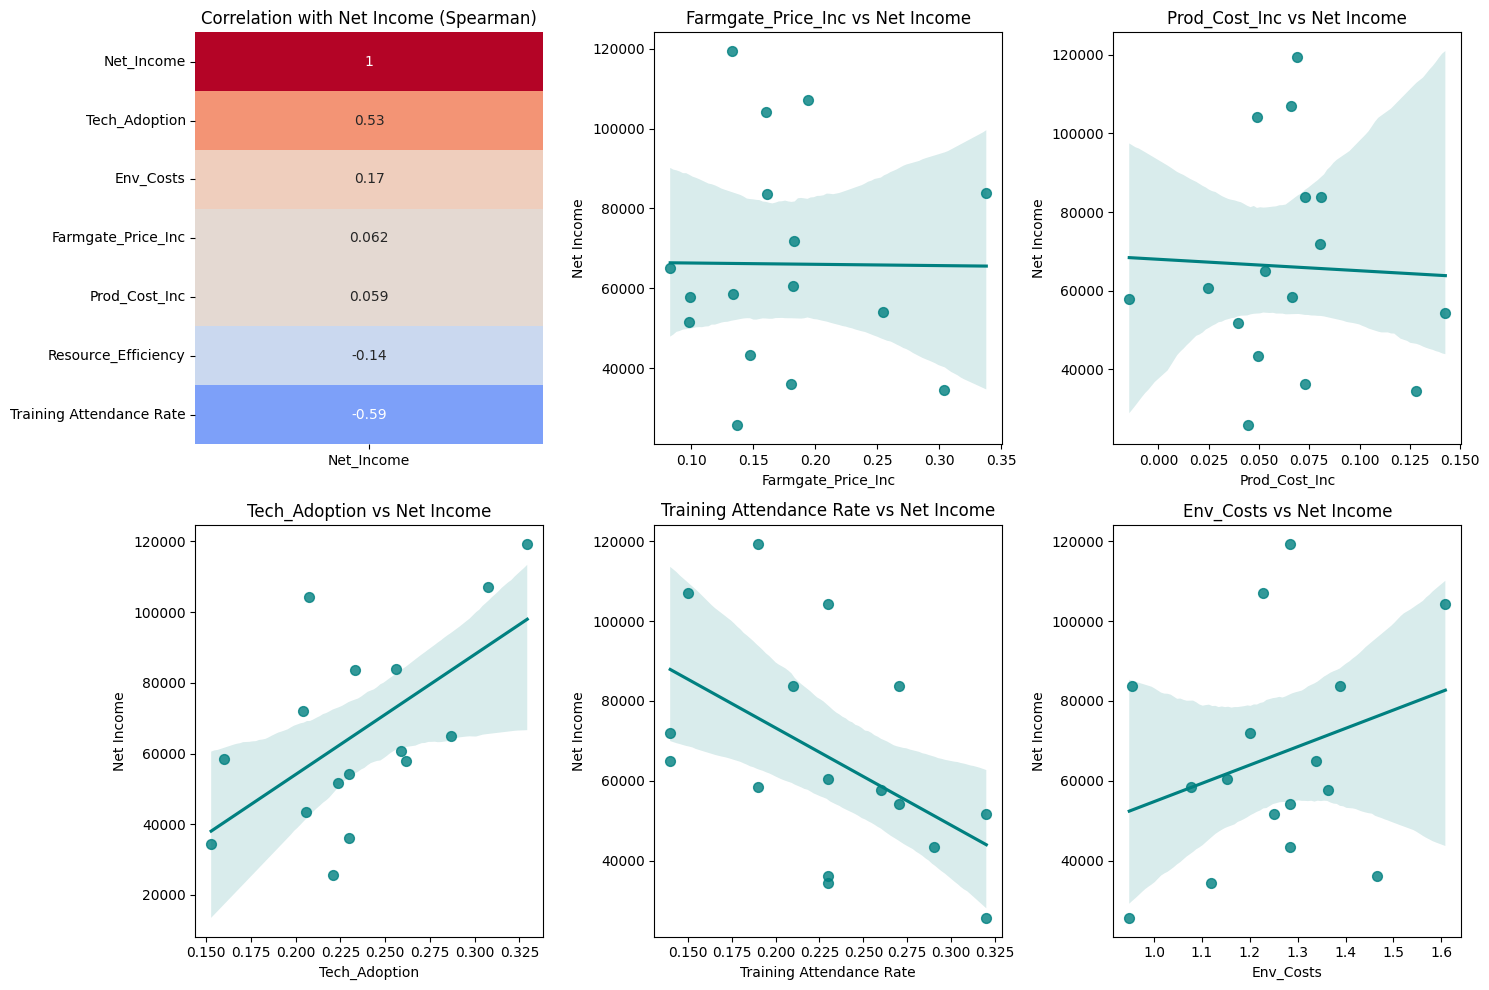

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import io
from scipy.stats import spearmanr

# 1. DATA LOADING & PREPARATION
data_content = """Region Type,Total of Rice Farmers per Region,Increase Rate in Farmgate Price per hectare,Increase Rate in Production Costs per hectare,Technology Adoption Rate,Training Attendance Rate,Fertilizers,Pesticides,Fuel & Oil,Irrigation Fee,Controlled Irrigation,Alternate-Wetting and Drying,Phosphorus,Potassium,Insecticide Application,Fungicide Application,Pesticide Application,Net Income (per hectare)
CAR,152267,0.180765,0.072866,0.2299,23%,0.0893,0.0241,0.0216,0,50.7%,1.5%,0.17,0.13,0.87,0.46,0.8,36192.24
Region 1,379908,0.194188,0.065939,0.3072,0.15,0.1435,0.0182,0.0352,0.0004,0.423,0.027,0.2,0.17,0.88,0.15,0.8,107088.36
Region 2,293351,0.083131,0.053179,0.2869,0.14,0.1286,0.0673,0.0291,0.0028,0.435,0.031,0.23,0.13,0.92,0.19,0.93,65091.27
Region 3,280312,0.133239,0.068825,0.3294,0.19,0.1564,0.0368,0.0392,0.0009,0.384,0.039,0.22,0.22,0.93,0.12,0.79,119375.78
CALABARZON,91086,0.137213,0.044676,0.2207,0.32,0.0952,0.0345,0.0175,0.001,75%,9.2%,0.12,0.11,0.78,0.02,0.8,25742.40
MIMAROPA,148719,0.181961,0.024883,0.2591,0.23,0.096,0.0494,0.0341,0.0031,0.613,2.6%,0.19,0.19,0.86,0.11,0.77,60590.05
Region 5,185869,0.147271,0.049758,0.2057,0.29,0.1192,0.041,0.0211,0.0028,0.533,0.026,0.16,0.15,0.91,0.19,0.9,43394.84
Region 6,417092,0.254912,0.142608,0.2297,0.27,0.1174,0.0296,0.017,0.0004,0.387,0.029,0.17,0.13,0.89,0.23,0.7,54194.89
Central Visayas,153673,0.303917,0.127921,0.1528,0.23,0.1021,0.0158,0.0088,0.0021,0.634,0.005,0.19,0.19,0.68,0.31,0.72,34482.65
Eastern Visayas,200350,0.13337,0.066418,0.1602,0.19,0.0737,0.0296,0.0135,0.001,0.601,0.017,0.13,0.1,0.9,0.06,0.77,58494.06
Zamboanga Peninsula,118942,0.182921,0.080451,0.2040,0.14,0.1051,0.0482,0.0128,0.005,0.544,0,0.14,0.17,0.9,0.13,0.93,71969.14
Northern Mindanao,82338,0.160037,0.04906,0.2077,0.23,0.1507,0.0334,0.0087,0.0055,0.724,0.091,0.18,0.17,0.89,0.52,0.9,104132.02
Davao Region,59882,0.16129,0.08106,0.233,0.21,0.1181,0.0516,0.0091,0.009,0.719,0.091,0.15,0.2,0.86,0.34,0.9,83735.84
SOCKSARGEN,185645,0.098995,-0.014452,0.2618,0.26,0.1152,0.1077,0.0129,0.0078,0.707,0.03,0.1,0.1,0.91,0.21,0.56,57818.54
CARAGA,96501,0.098473,0.039782,0.2237,0.32,0.0965,0.0599,0.0214,0.0024,0.771,0.121,0.15,0.18,0.92,0.15,0.78,51654.36
BARMM,67206,0.337984,0.072808,0.2562,0.27,0.0998,0.0571,0.0052,0.0017,0.527,0.034,0.1,0.11,0.71,0.08,0.39,83866.79"""

df = pd.read_csv(io.StringIO(data_content))

# Data Cleaning
def clean_percent(x):
    if isinstance(x, str) and '%' in x:
        return float(x.replace('%', '')) / 100
    return float(x)

cols_to_clean = ['Training Attendance Rate', 'Controlled Irrigation', 'Alternate-Wetting and Drying']
for col in cols_to_clean:
    df[col] = df[col].apply(clean_percent)

df = df.rename(columns={
    'Increase Rate in Farmgate Price per hectare': 'Farmgate_Price_Inc',
    'Increase Rate in Production Costs per hectare': 'Prod_Cost_Inc',
    'Technology Adoption Rate': 'Tech_Adoption',
    'Net Income (per hectare)': 'Net_Income'
})

# Feature Engineering
env_components = ['Fertilizers', 'Pesticides', 'Fuel & Oil', 'Irrigation Fee', 'Insecticide Application', 'Fungicide Application']
df['Env_Costs'] = df[env_components].sum(axis=1)

resource_components = ['Tech_Adoption', 'Controlled Irrigation', 'Alternate-Wetting and Drying']
df['Resource_Efficiency'] = df[resource_components].mean(axis=1)

# 2. STATISTICAL ANALYSIS (Spearman Correlation)
target_var = 'Net_Income'
predictors = [
    'Farmgate_Price_Inc', 
    'Prod_Cost_Inc', 
    'Tech_Adoption',
    'Training Attendance Rate',
    'Env_Costs', 
    'Resource_Efficiency'
]

results = []
for var in predictors:
    corr, p_val = spearmanr(df[var], df[target_var])
    results.append({
        'Variable': var,
        'Spearman_Correlation': corr,
        'P-Value': p_val,
        'Significant': 'Yes' if p_val < 0.05 else 'No'
    })

results_df = pd.DataFrame(results)

# 3. VISUALIZATION
# Set up the matplotlib figure
plt.figure(figsize=(15, 10))

# A. Correlation Heatmap
plt.subplot(2, 3, 1) # Position 1
corr_matrix = df[predictors + [target_var]].corr(method='spearman')
sns.heatmap(corr_matrix[[target_var]].sort_values(by=target_var, ascending=False), 
            annot=True, cmap='coolwarm', vmin=-1, vmax=1, cbar=False)
plt.title('Correlation with Net Income (Spearman)')

# B. Scatter Plots for Top Relationships
# Let's plot the top 5 most interesting ones to fit the grid
plot_positions = [2, 3, 4, 5, 6]

for i, var in enumerate(predictors[:5]): # Plot first 5 predictors
    plt.subplot(2, 3, plot_positions[i])
    sns.regplot(x=var, y=target_var, data=df, color='teal', scatter_kws={'s':50})
    plt.title(f'{var} vs Net Income')
    plt.xlabel(var)
    plt.ylabel('Net Income')

plt.tight_layout()
plt.savefig('analysis_results.png')

print("Statistical Analysis Results (Spearman Rank Correlation):")
print(results_df)

                Factor          SOP_Category  Correlation Impact_Level  \
0  Technology Adoption  SOP 1: Opportunities         0.53     Moderate   
1  Training Attendance  SOP 1: Opportunities        -0.59     Moderate   
2  Farmgate Price Inc.     SOP 1: Challenges         0.06    Very Weak   
3      Prod. Cost Inc.     SOP 1: Challenges         0.06    Very Weak   
4  Environmental Costs     SOP 2: Green Acct         0.17    Very Weak   
5  Resource Efficiency     SOP 2: Green Acct        -0.14    Very Weak   

   Significant  
0         True  
1         True  
2        False  
3        False  
4        False  
5        False  


/var/folders/j3/kwprsg3s3_zf9_90gxwcknm00000gn/T/ipykernel_42987/1642800361.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Correlation', y='Factor', data=df_impact, palette=colors.tolist())


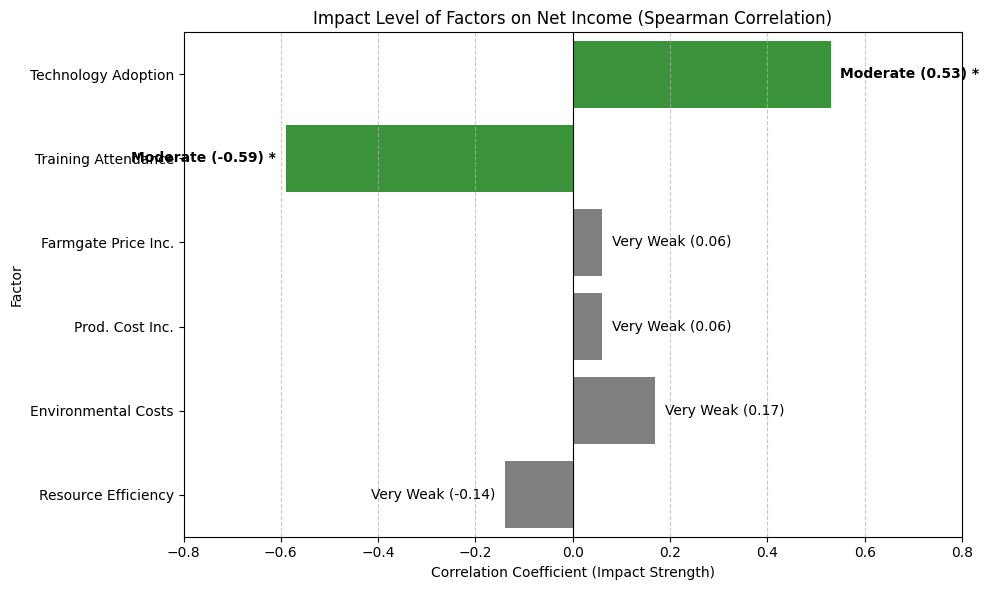

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Data from previous analysis
data = {
    'Factor': ['Technology Adoption', 'Training Attendance', 'Farmgate Price Inc.', 
               'Prod. Cost Inc.', 'Environmental Costs', 'Resource Efficiency'],
    'SOP_Category': ['SOP 1: Opportunities', 'SOP 1: Opportunities', 'SOP 1: Challenges', 
                     'SOP 1: Challenges', 'SOP 2: Green Acct', 'SOP 2: Green Acct'],
    'Correlation': [0.53, -0.59, 0.06, 0.06, 0.17, -0.14],
    'P_Value': [0.035, 0.016, 0.820, 0.829, 0.535, 0.610]
}

df_impact = pd.DataFrame(data)

# Define Impact Level function (Evans, 1996 standard)
def get_impact_level(rho):
    abs_rho = abs(rho)
    if abs_rho < 0.20: return "Very Weak"
    elif abs_rho < 0.40: return "Weak"
    elif abs_rho < 0.60: return "Moderate"
    elif abs_rho < 0.80: return "Strong"
    else: return "Very Strong"

df_impact['Impact_Level'] = df_impact['Correlation'].apply(get_impact_level)
df_impact['Significant'] = df_impact['P_Value'] < 0.05

# Visualization
plt.figure(figsize=(10, 6))
colors = df_impact['Significant'].map({True: '#2ca02c', False: '#7f7f7f'}) # Green for significant, Gray for not

# Create Bar Plot
sns.barplot(x='Correlation', y='Factor', data=df_impact, palette=colors.tolist())

# Add labels
for i, row in enumerate(df_impact.itertuples()):
    # Position text based on positive or negative bar
    offset = 0.02 if row.Correlation >= 0 else -0.02
    align = 'left' if row.Correlation >= 0 else 'right'
    
    label = f"{row.Impact_Level} ({row.Correlation:.2f})"
    if row.Significant:
        label += " *"
        
    plt.text(row.Correlation + offset, i, label, va='center', ha=align, fontsize=10, fontweight='bold' if row.Significant else 'normal')

plt.axvline(0, color='black', linewidth=0.8)
plt.title('Impact Level of Factors on Net Income (Spearman Correlation)')
plt.xlabel('Correlation Coefficient (Impact Strength)')
plt.xlim(-0.8, 0.8)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('impact_analysis.png')

print(df_impact[['Factor', 'SOP_Category', 'Correlation', 'Impact_Level', 'Significant']])